# Fine-Tune Pretrained Commutative CNN Classifier

Load the pretrained commutative CNN encoder and fine-tune the full network on the current labeled action dataset.

In [1]:
%load_ext autoreload
%autoreload 2

from dataclasses import asdict
from pathlib import Path

import pandas as pd

from src.ml import (
    CommutativeCNNClassifier,
    LossWeightConfig,
    OptimizationConfig,
    display_experiment_summary,
    display_holdout_evaluation,
    fit_chunked_water_vs_other_hot_start,
    fit_estimator_on_experiment,
    load_commutative_cnn_pretraining_config,
    persist_experiment_artifacts,
    plot_training_history,
    prepare_multitask_experiment_data,
    prepare_water_vs_other_pretraining_data,
)
from src.dataset_config import load_current_dataset_artifact_path
from src.tensor_utils import (
    build_tensor_embedding_2d,
    load_labeled_tensor_dataset,
    plot_tensor_embedding_2d,
)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.set_option("display.expand_frame_repr", False)


In [2]:
# User inputs

dataset_artifact_path = load_current_dataset_artifact_path()
unlabeled_dataset_path = Path(".dataset_cache/unlabeled_active_high_mid_low_t20_z5_y96_x96_chunks")
pretraining_config_path = Path("artifacts/pretrained_commutative_cnn/config.yaml")
pretraining_config = load_commutative_cnn_pretraining_config(pretraining_config_path)
print(f"Loaded commutative CNN pretraining config from {pretraining_config_path}")
print(pretraining_config)

pretrained_encoder_path = pretraining_config.pretrained_encoder_path
if not pretrained_encoder_path.exists():
    raise FileNotFoundError(
        f"Pretrained CNN encoder not found at {pretrained_encoder_path}. "
        "Run 10C_pretrain_commutative_cnn_encoder.ipynb first, or update "
        "artifacts/pretrained_commutative_cnn/config.yaml to point at an existing checkpoint."
    )
model_config = pretraining_config.model_config
experiment_output_dir = Path("artifacts/nb13C_commutative_cnn_full_finetune")
binary_loss_plot_dir = experiment_output_dir / "loss_plots" / "binary_hot_start"
fine_tune_loss_plot_dir = experiment_output_dir / "loss_plots" / "fine_tune"
persist_artifacts = True
print(f"Using pretrained encoder checkpoint: {pretrained_encoder_path.resolve()}")
print(f"Binary hot-start loss PDFs: {binary_loss_plot_dir.resolve()}")
print(f"Fine-tune loss PDFs: {fine_tune_loss_plot_dir.resolve()}")

holdout_fraction = 0.25
validation_fraction_within_train = 0.20
train_num_random_rotations = 4
rotation_range_degrees = 12.0
run_binary_hot_start = True
binary_pretraining_epochs = 10
binary_learning_rate = 5e-5
binary_weight_decay = 3e-4
binary_class_weighting = "balanced"

optimization_config = OptimizationConfig(
    batch_size=8,
    epochs=100,
    learning_rate=1e-4,
    weight_decay=3e-4,
    early_stopping_patience=12,
    early_stopping_min_delta=5e-4,
    early_stopping_start_epoch=12,
    early_stopping_monitor="action_loss",
    early_stopping_smoothing="median",
    early_stopping_smoothing_window=5,
    scheduler_patience=4,
    scheduler_factor=0.7,
    scheduler_min_lr=1e-6,
    training_plot_dir=str(fine_tune_loss_plot_dir),
    training_plot_every_n_epochs=1,
    validation_split=0.0,
    random_state=0,
    standardize=True,
    device=None,
    verbose=True,
    class_weighting="balanced",
)
loss_weight_config = LossWeightConfig(
    action_weight=1.0,
    compound_weight=0.1,
    concentration_weight=0.05,
    lambda_align=0.01,
)


Loaded commutative CNN pretraining config from artifacts/pretrained_commutative_cnn/config.yaml
CommutativeCNNPretrainingConfig(unlabeled_dataset_path=PosixPath('.dataset_cache/unlabeled_active_high_mid_low_t20_z5_y96_x96_chunks'), pretrained_encoder_path=PosixPath('artifacts/pretrained_commutative_cnn/encoder_state_v6.pt'), validation_fraction=0.15, train_num_random_rotations=0, rotation_range_degrees=0.0, model_config=CommutativeCNNConfig(spatial_conv_channels=(16, 32), spatial_kernel_size_z=(3, 1), spatial_kernel_size_xy=(5, 3), spatial_stride_z=(1, 1), spatial_stride_xy=(1, 1), spatial_pool_kernel_z=(1, 1), spatial_pool_kernel_xy=(2, 2), spatial_pool_stride_z=(1, 1), spatial_pool_stride_xy=(2, 2), temporal_st_channels=(48, 64), temporal_st_kernel_sizes=(5, 3), temporal_ts_channels=(32, 48, 64), temporal_ts_kernel_sizes=(7, 5, 3), spatial_agg_channels=(32, 64), spatial_agg_kernel_size_z=(3, 1), spatial_agg_kernel_size_xy=(3, 3), spatial_agg_stride_z=(1, 1), spatial_agg_stride_xy=(1,

In [3]:
dataset = load_labeled_tensor_dataset(dataset_artifact_path)
experiment = prepare_multitask_experiment_data(
    dataset,
    holdout_fraction=holdout_fraction,
    validation_fraction_within_train=validation_fraction_within_train,
    train_num_random_rotations=train_num_random_rotations,
    rotation_range_degrees=rotation_range_degrees,
    random_state=optimization_config.random_state,
)
display_experiment_summary(experiment)

,split,n_samples
0,train_augmented,504
1,train_base,168
2,val,42
3,holdout,71


,mechanism_of_action,compound,concentration_band,n_samples
0,GABAAR_Antagonist,Gabazine,high,21
1,GABAAR_Antagonist,Bemegride,control,21
2,AChE_Inhibitor_Reversible,Galantamine,high,18
3,GABAAR_Antagonist,Gabazine,control,18
4,mAChR_Agonist_NonSelective,Bethanechol,high,18
5,mAChR_Agonist_NonSelective,Bethanechol,mid,18
6,mAChR_Agonist_NonSelective,Muscarine,high,18
7,NMDAR_Activation,Cis-ACPD,control,18
8,mAChR_Agonist_NonSelective,Pilocarpine,high,15
9,mAChR_Agonist_NonSelective,Bethanechol,control,15


## Memory Note

The unlabeled pretraining chunks are large and `load_unlabeled_tensor_dataset(...)` concatenates them into one CPU tensor. This notebook keeps the intended water-vs-other hot-start, but runs it with `fit_chunked_water_vs_other_hot_start(...)`, which scans and trains from chunks instead of materializing the full unlabeled tensor in RAM. Supervised rotation augmentation is reduced because it materializes augmented labeled tensors in memory before fitting.

Writing binary hot-start loss PDFs to: /run/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/ZebraFish/artifacts/nb13C_commutative_cnn_full_finetune/loss_plots/binary_hot_start
Binary hot-start optimizer: lr=0.0001, weight_decay=0.0003, class_weighting=balanced
Commutative CNN model: parameters=170,122 trainable=170,122 size=0.65 MB
001/020 lr=1.00e-04 eta=4:55:30 train_loss=0.6886 val_loss=0.8205 train_acc=0.719 val_acc=0.410
002/020 lr=1.00e-04 eta=4:52:19 train_loss=0.6763 val_loss=0.7400 train_acc=0.733 val_acc=0.518
003/020 lr=1.00e-04 eta=4:35:43 train_loss=0.6663 val_loss=1.0422 train_acc=0.724 val_acc=0.508
004/020 lr=1.00e-04 eta=4:15:37 train_loss=0.6672 val_loss=0.8780 train_acc=0.715 val_acc=0.246
005/020 lr=1.00e-04 eta=4:02:30 train_loss=0.6706 val_loss=0.8365 train_acc=0.725 val_acc=0.646
006/020 lr=1.00e-04 eta=3:46:12 train_loss=0.6678 val_loss=0.9043 train_acc=0.718 val_acc=0.718
007/020 lr=1.00e-04 eta=3:29:19 train_loss=0.6626 val_loss=0.8551 t

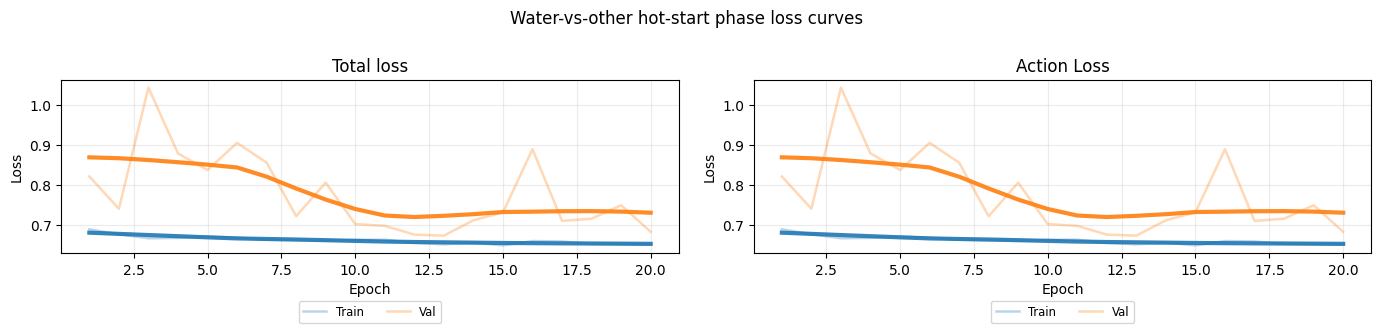

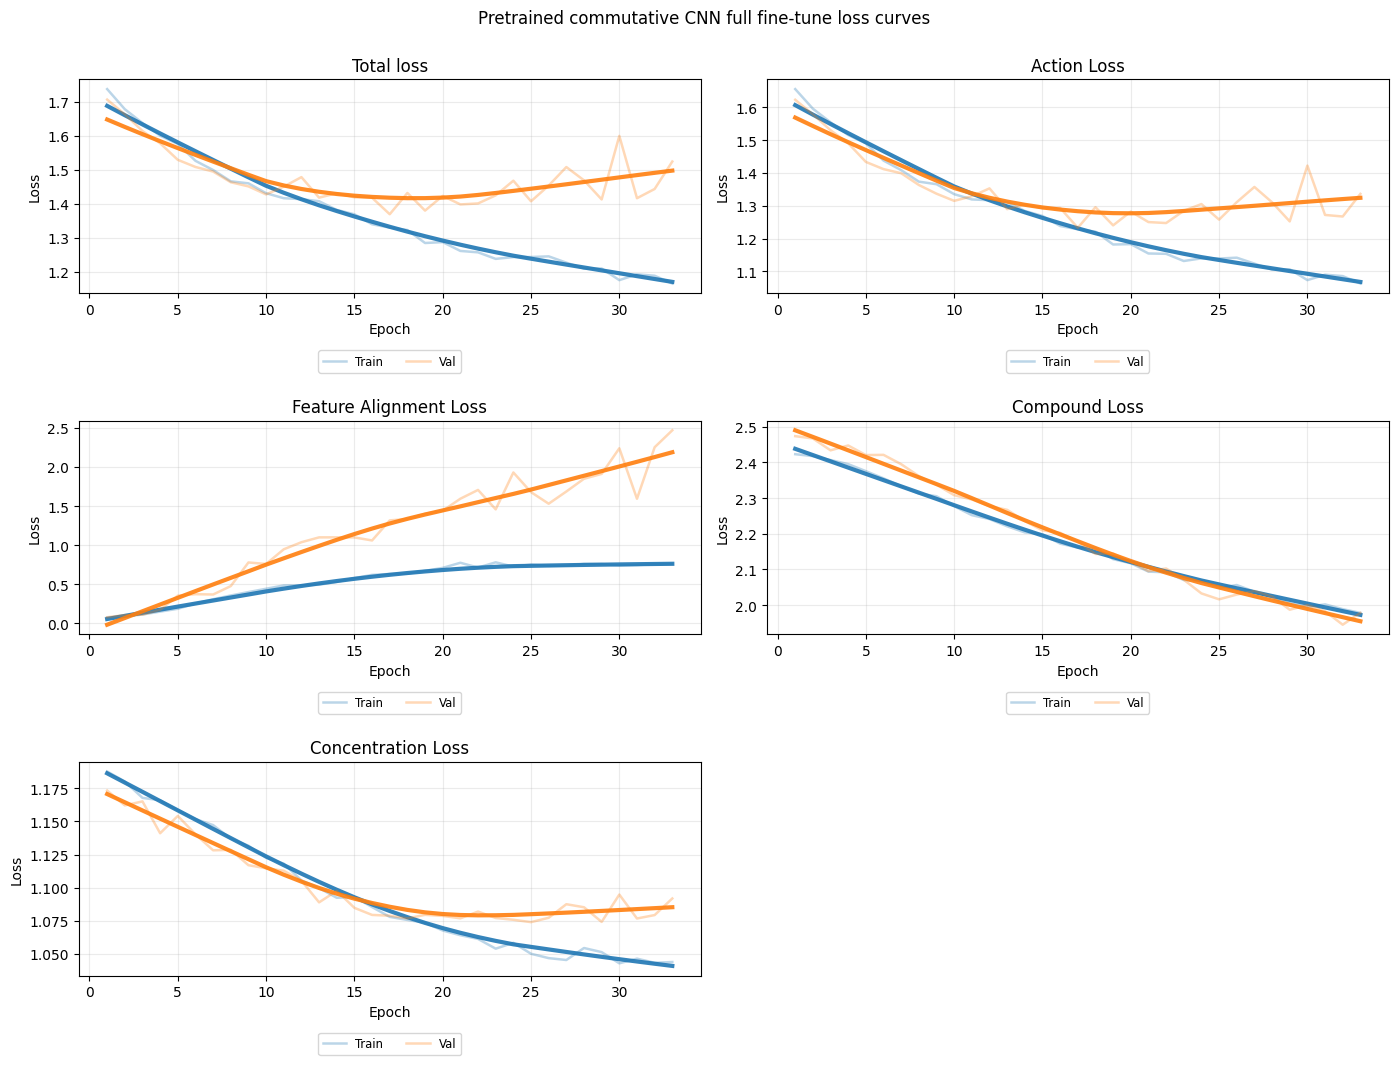

In [4]:
model = CommutativeCNNClassifier(
    model_config=model_config,
    optimization_config=optimization_config,
    loss_weight_config=loss_weight_config,
    pretrained_state_path=pretrained_encoder_path,
    freeze_backbone=False,
    hot_start=True,
)

binary_pretraining_data = None
binary_pretraining_history = None
if run_binary_hot_start and binary_pretraining_epochs > 0:
    final_epochs = model.epochs
    final_learning_rate = model.learning_rate
    final_weight_decay = model.weight_decay
    model.training_plot_dir = str(binary_loss_plot_dir)
    model.training_plot_title = "Water-vs-other hot-start loss curves"
    model.learning_rate = binary_learning_rate
    model.weight_decay = binary_weight_decay
    print(f"Writing binary hot-start loss PDFs to: {binary_loss_plot_dir.resolve()}")
    print(f"Binary hot-start optimizer: lr={model.learning_rate:g}, weight_decay={model.weight_decay:g}, class_weighting={binary_class_weighting}")
    binary_pretraining_data = fit_chunked_water_vs_other_hot_start(
        model,
        unlabeled_dataset_path,
        holdout_metadata=experiment.splits.metadata_holdout,
        validation_fraction=validation_fraction_within_train,
        epochs=binary_pretraining_epochs,
        random_state=optimization_config.random_state,
        class_weighting=binary_class_weighting,
    )
    binary_pretraining_history = model.history_.copy()
    plot_training_history(model, title="Water-vs-other hot-start phase loss curves", loess_frac=0.6);
    model.epochs = final_epochs
    model.learning_rate = final_learning_rate
    model.weight_decay = final_weight_decay

model.training_plot_dir = str(fine_tune_loss_plot_dir)
model.training_plot_title = "Pretrained commutative CNN full fine-tune loss curves"
print(f"Writing fine-tune loss PDFs to: {fine_tune_loss_plot_dir.resolve()}")
fit_estimator_on_experiment(model, experiment)
plot_training_history(model, title="Pretrained commutative CNN full fine-tune loss curves", loess_frac=0.6);



## Holdout report: action


,precision,recall,f1-score,support
class,,,,
Water,0.418182,0.920000,0.575000,25.0
GABAAR_Antagonist,0.666667,0.166667,0.266667,12.0
NMDAR_Activation,0.800000,0.800000,0.800000,10.0
AChE_Inhibitor_Reversible,0.500000,0.083333,0.142857,12.0
mAChR_Agonist_NonSelective,1.000000,0.083333,0.153846,12.0


,value
accuracy,0.492958
macro_precision,0.676970
macro_recall,0.410667
macro_f1,0.387674
weighted_precision,0.626120
weighted_recall,0.492958
weighted_f1,0.410358
n_samples,71.000000
roc_auc_ovr_macro,0.796608
average_precision_macro,0.578125


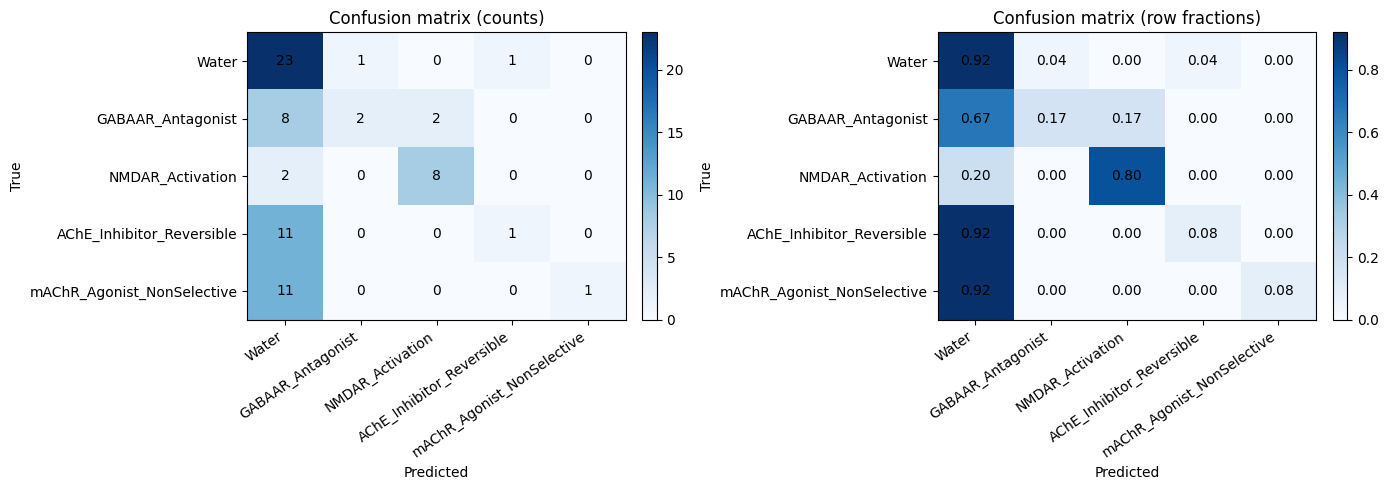


## Holdout report: compound


,precision,recall,f1-score,support
class,,,,
Control,0.367647,1.0,0.537634,25.0
Bemegride,0.000000,0.0,0.000000,6.0
Bicuculline,0.000000,0.0,0.000000,3.0
Gabazine,0.000000,0.0,0.000000,3.0
(RS)-(Tetrazol-5-yl)glycine,0.000000,0.0,0.000000,3.0
Cis-ACPD,0.000000,0.0,0.000000,3.0
N-methyl-D-aspartate,1.000000,0.5,0.666667,4.0
Donepezil,0.000000,0.0,0.000000,4.0
Galantamine,0.000000,0.0,0.000000,4.0


,value
accuracy,0.380282
macro_precision,0.105204
macro_recall,0.115385
macro_f1,0.092639
weighted_precision,0.185791
weighted_recall,0.380282
weighted_f1,0.226867
n_samples,71.000000
roc_auc_ovr_macro,0.750581
average_precision_macro,0.319625


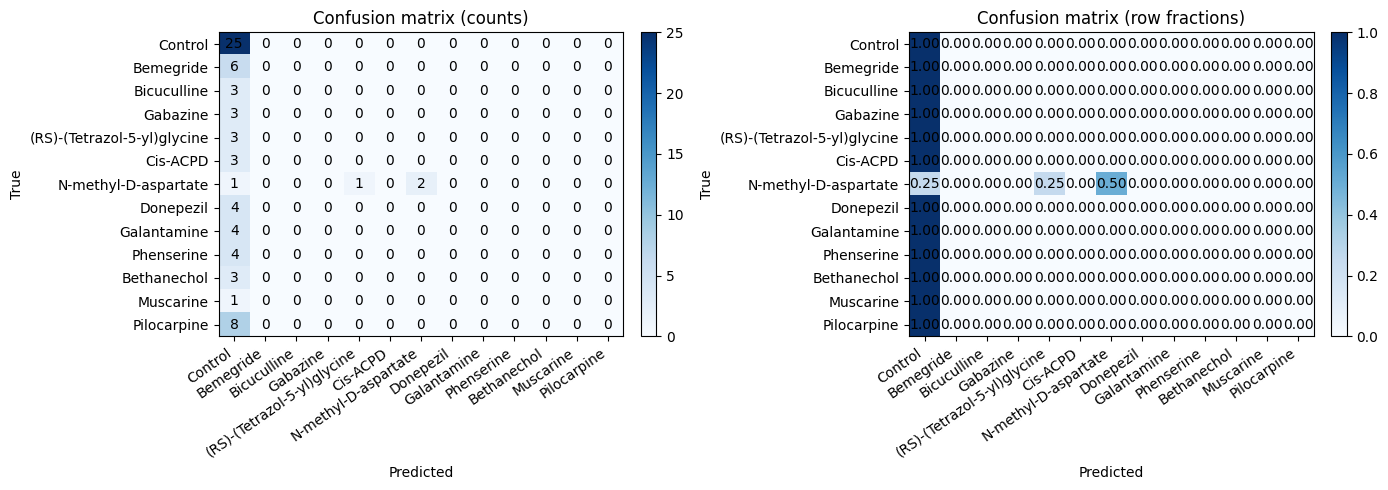


## Holdout report: concentration


,precision,recall,f1-score,support
class,,,,
control,0.413793,0.96,0.578313,25.0
high,0.666667,0.24,0.352941,25.0
mid,0.000000,0.00,0.000000,21.0


,value
accuracy,0.422535
macro_precision,0.360153
macro_recall,0.400000
macro_f1,0.310418
weighted_precision,0.380444
weighted_recall,0.422535
weighted_f1,0.327906
n_samples,71.000000
roc_auc_ovr_macro,0.556867
average_precision_macro,0.403396


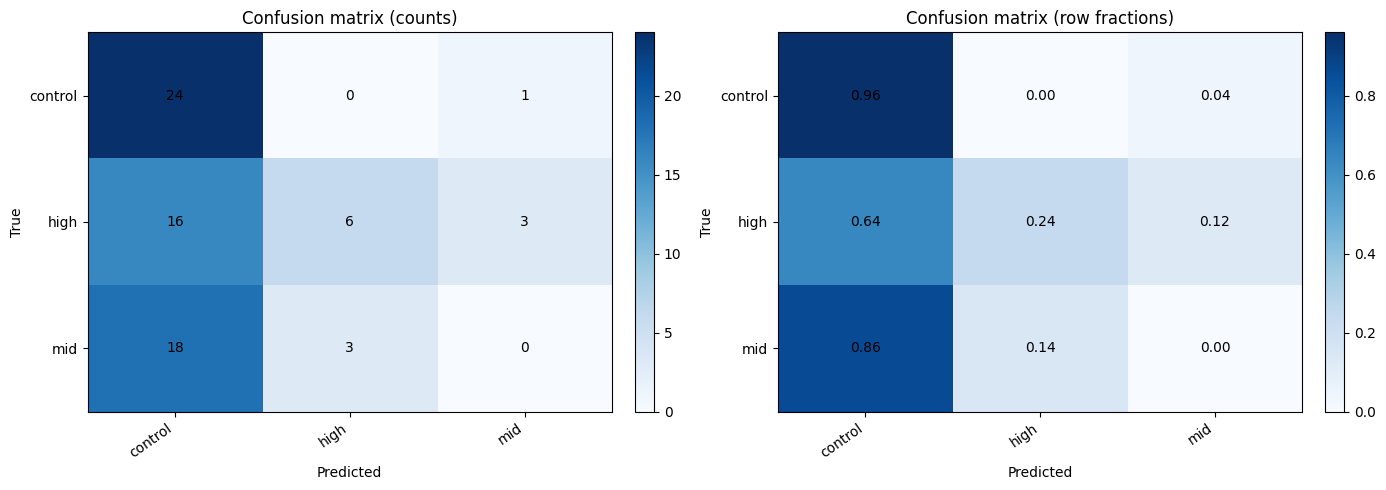

In [5]:
holdout_evaluation = display_holdout_evaluation(model, experiment)

(<Figure size 1550x1050 with 1 Axes>,
 <Axes: title={'center': 'Holdout embedding projection by action'}, xlabel='Component 1', ylabel='Component 2'>)

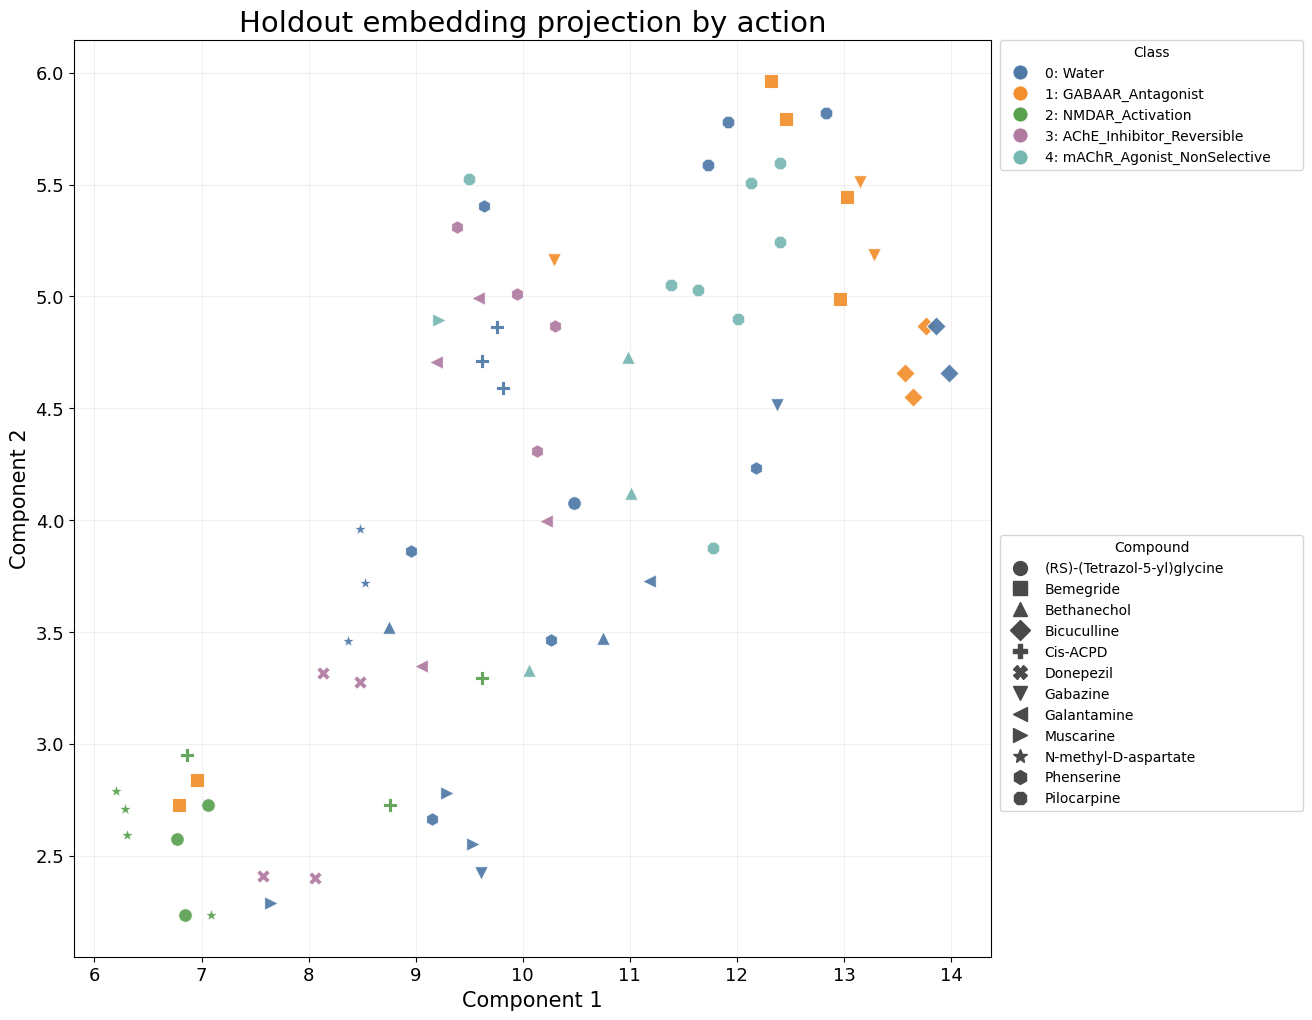

In [6]:
holdout_embedding_projection = build_tensor_embedding_2d(
    model.transform(experiment.splits.X_holdout),
    experiment.y_true_holdout["action"],
    label_map=experiment.label_maps["action"],
    metadata=experiment.splits.metadata_holdout,
    method="umap",
    random_state=optimization_config.random_state,
)
plot_tensor_embedding_2d(
    holdout_embedding_projection,
    title="Holdout embedding projection by action",
    marker_column="compound",
)

In [7]:
run_config = {
    "dataset_artifact_path": dataset_artifact_path,
    "unlabeled_dataset_path": unlabeled_dataset_path,
    "pretraining_config_path": pretraining_config_path,
    "pretrained_encoder_path": pretrained_encoder_path,
    "binary_loss_plot_dir": binary_loss_plot_dir,
    "fine_tune_loss_plot_dir": fine_tune_loss_plot_dir,
    "freeze_backbone": False,
    "hot_start": True,
    "run_binary_hot_start": run_binary_hot_start,
    "binary_pretraining_epochs": binary_pretraining_epochs,
    "binary_learning_rate": binary_learning_rate,
    "binary_weight_decay": binary_weight_decay,
    "binary_class_weighting": binary_class_weighting,
    "binary_pretraining_excluded_holdout_count": None if binary_pretraining_data is None else binary_pretraining_data.excluded_holdout_count,
    "binary_pretraining_label_map": None if binary_pretraining_data is None else binary_pretraining_data.label_map,
    "binary_pretraining_train_count": None if binary_pretraining_data is None else binary_pretraining_data.train_count,
    "binary_pretraining_val_count": None if binary_pretraining_data is None else binary_pretraining_data.val_count,
    "holdout_fraction": holdout_fraction,
    "validation_fraction_within_train": validation_fraction_within_train,
    "train_num_random_rotations": train_num_random_rotations,
    "rotation_range_degrees": rotation_range_degrees,
    "model_config": asdict(model_config),
    "optimization_config": asdict(optimization_config),
    "loss_weight_config": asdict(loss_weight_config),
}
if persist_artifacts:
    experiment_artifacts = persist_experiment_artifacts(
        output_dir=experiment_output_dir,
        estimator=model,
        reports=holdout_evaluation.reports,
        config=run_config,
    )
    if binary_pretraining_history is not None:
        binary_pretraining_history.to_csv(experiment_output_dir / "binary_pretraining_history.csv", index=False)
    experiment_artifacts
